# Credit Card Customer Churn Analysis
## Exploratory Data Analysis (EDA)

**Project Goal:**  
Analyze customer behavior and identify patterns related to churn in a credit card portfolio.

**Business Context:**  
Customer churn is costly for banks. Understanding why customers leave helps improve retention strategies, profitability, and customer satisfaction.

**Author:** Your Name  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Date:** April 2026

##  Business Understanding

### Objective

This project investigates factors influencing customer churn in a credit card business.

#### Key Questions:

- What percentage of customers churned?
- Which customer groups churn the most?
- Which behavioral indicators signal churn risk?
- What business actions can reduce churn?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')


## 2. Load Data

In [2]:
df = pd.read_csv('/Users/reyhaneh/Documents/Machine_Learning/Credit_Card_Churn/data/credit_card_churn.csv')

## 3. Initial Data Inspection

This section provides a first overview of the dataset structure, variable names, data types, and general data quality.

In [3]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (10127, 23)


In [5]:
df.columns.tolist()

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                                      

In [7]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


## 4. Data Cleaning

In this section, irrelevant columns are removed and variables are prepared for analysis.

### 4.1 Remove irrelevant columns

In [8]:
# Remove CLIENTNUM & Naive Bayes columns
df.drop(columns=['CLIENTNUM'], inplace=True)
df = df.loc[:, ~df.columns.str.contains('Naive')]


### 4.2 Check Duplicates

In [9]:
is_duplicate = df.duplicated().sum()
if is_duplicate > 0:
    df = df.drop_duplicates()
    print(f"Number of duplicates removed: {is_duplicate}")
else:
    print("No duplicates found")

No duplicates found


### 4.3 Check Missing Values

In [10]:
is_missing = df.isnull().sum()
if is_missing.sum() > 0:
    print("Missing values found in the following columns:")
    print(is_missing[is_missing > 0])
else:
    print("No missing values found")

No missing values found


### 4.4 Convert Target Variable 

In [11]:
df['Churn'] = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})
df.drop(columns=['Attrition_Flag'], inplace=True)

In [12]:
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## 5. Univariate Analysis

This section explores individual variables to better understand customer characteristics and portfolio composition.

### Target Variable Distribution

In [13]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)

Churn
0    8500
1    1627
Name: count, dtype: int64
Churn
0    83.934038
1    16.065962
Name: proportion, dtype: float64


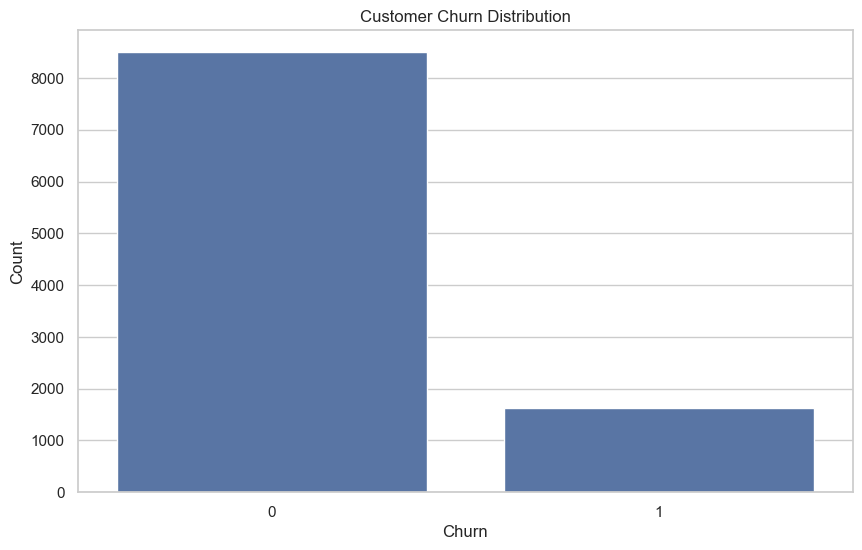

In [14]:
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

### Insight

The target variable shows that approximately **84% of customers remained active**, while only **16% churned** (1,627 customers).

This indicates a **class imbalance**, which is important for the later machine learning phase.  
If not handled properly, predictive models may become biased toward the majority class (non-churn customers) and fail to identify customers at risk of leaving.

### Numerical Variables Distributions

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio',
 'Churn']

In [16]:
df.columns.to_list()

['Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio',
 'Churn']

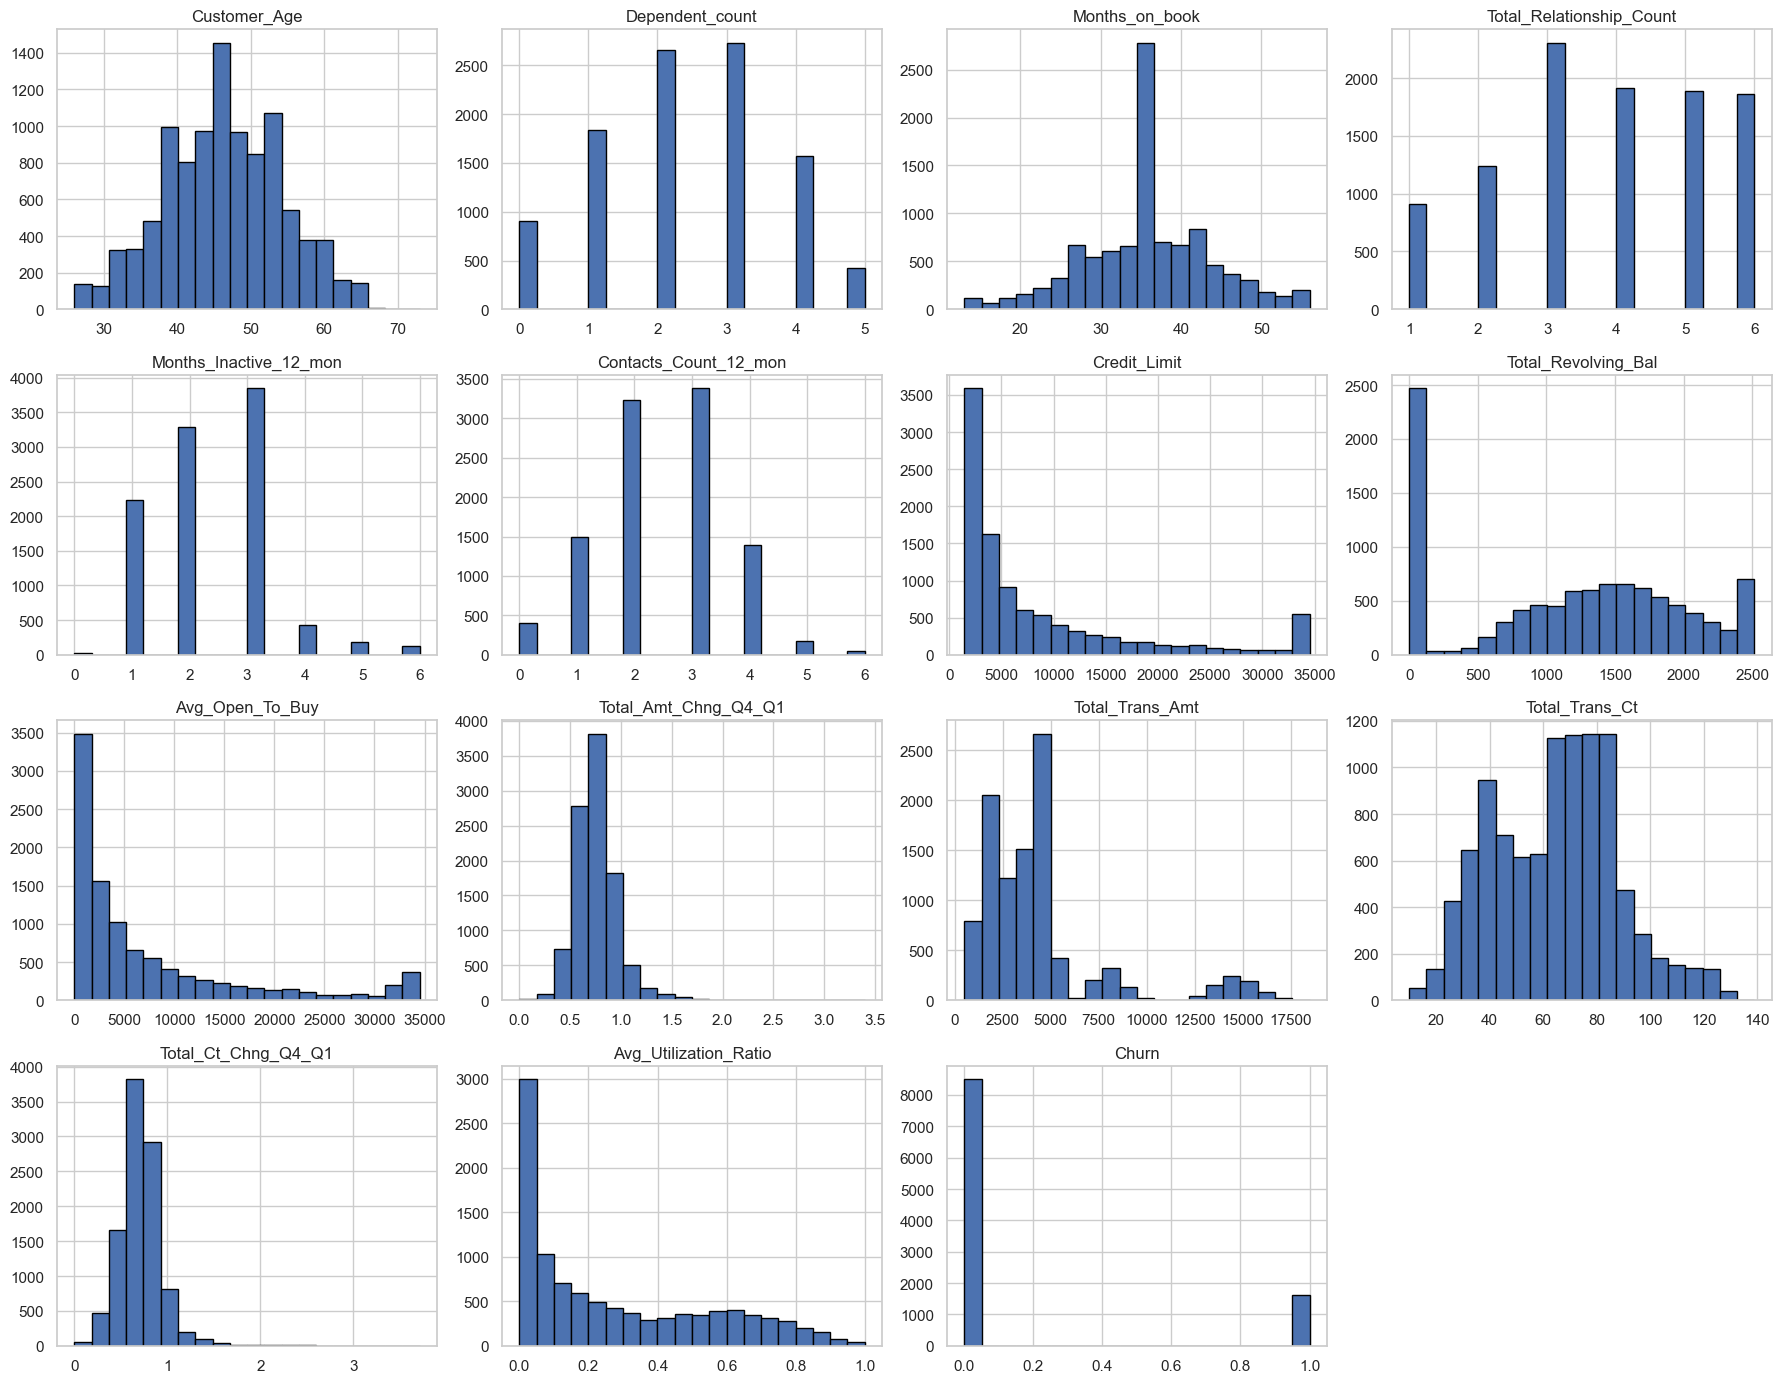

In [17]:
df[num_cols].hist(figsize=(18, 14), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

### Key Insights from Numerical Distributions

- Most customers are between **40 and 55 years old**, indicating a mature customer base.
- Customer tenure peaks around **36 months**, suggesting many mid-term customer relationships.
- Credit limits are highly right-skewed, with a smaller premium segment holding very high limits.
- Transaction counts are concentrated around moderate activity levels.
- A significant share of customers shows low utilization ratios, meaning much of the available credit remains unused.
- Most customers were inactive for **1 to 3 months** during the last 12 months, while a smaller segment shows higher inactivity levels that should be investigated further.

### Behavioral Change Insight

The variables **Total_Amt_Chng_Q4_Q1** and **Total_Ct_Chng_Q4_Q1** capture changes in customer transaction behavior compared to the previous quarter.

Most customers show ratios around **0.7 to 0.8**, indicating a moderate decline in activity.

Customers with ratios below **0.5** may represent an early-warning segment, as their transaction volume or transaction frequency has dropped substantially.

These behavioral change metrics could be highly valuable for a proactive churn monitoring system, enabling intervention before customers become fully inactive.

### Categorical Variable Distributions

In [18]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

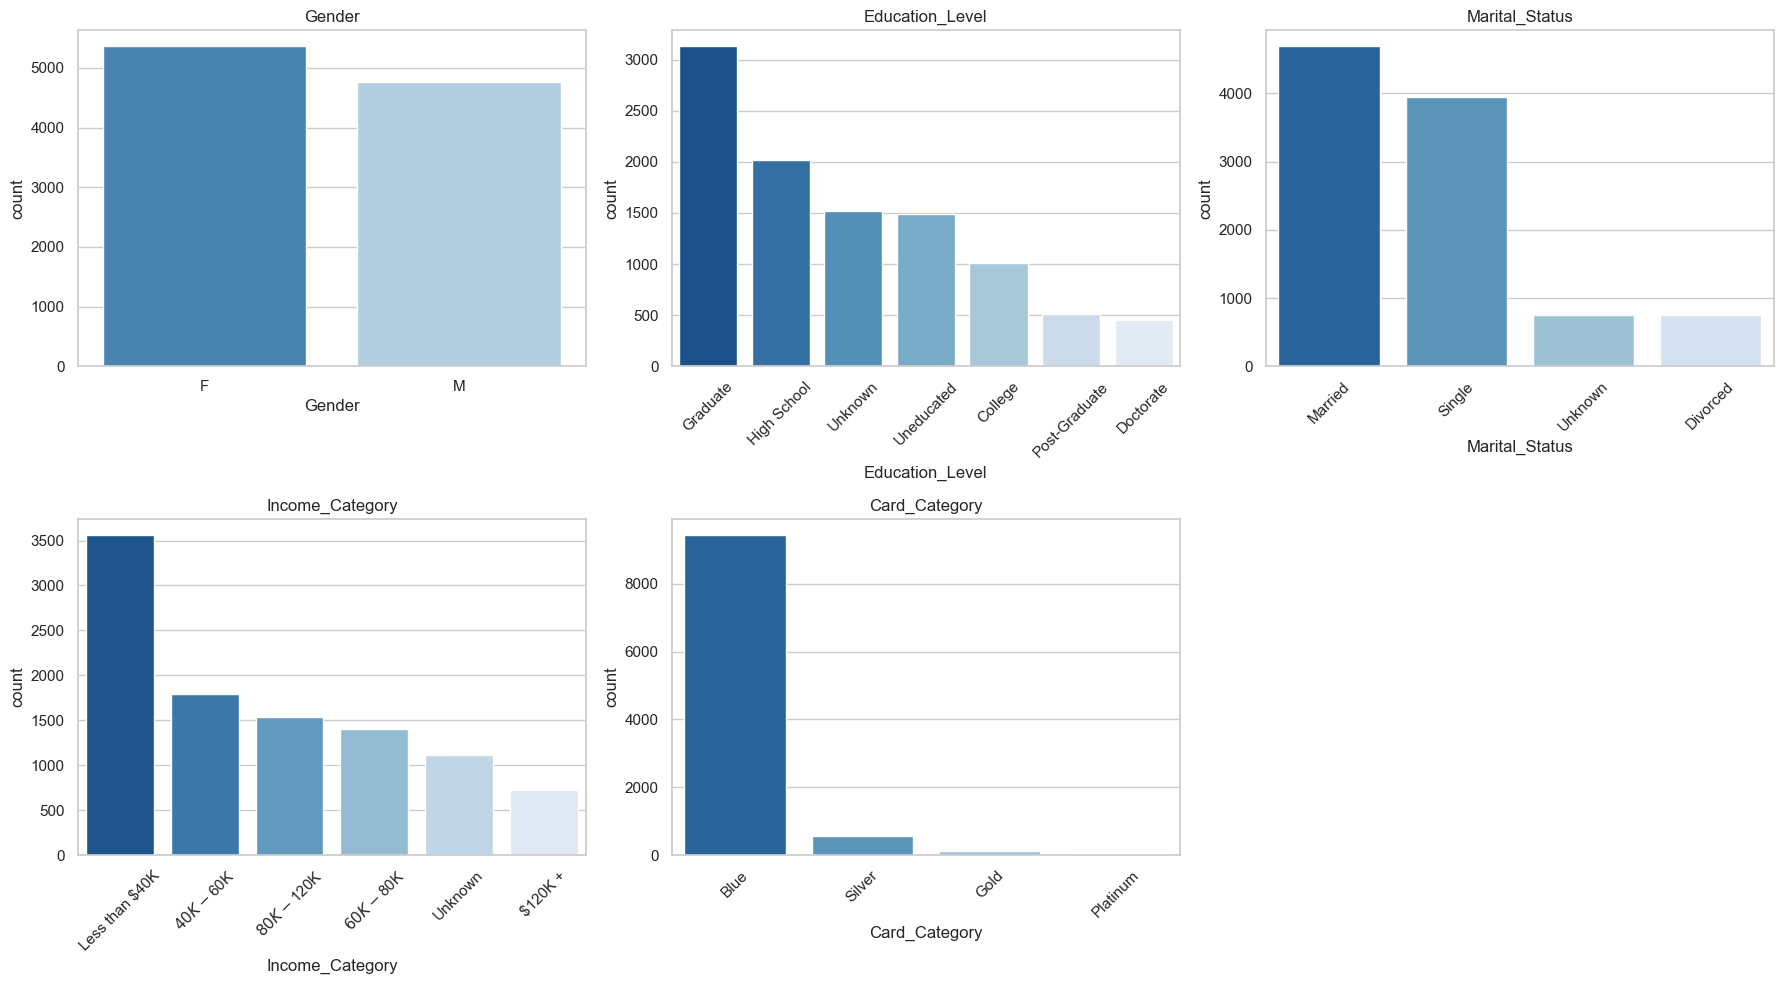

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        ax=axes[i],
        palette="Blues_r"
    )
    
    axes[i].set_title(f"{col}")
    n_cats = df[col].nunique(dropna=False)
    if n_cats >= 4:
        axes[i].tick_params(axis="x", rotation=45)

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### Key Insights from Categorical Variable Distributions

- The customer base is quite balanced by gender, with slightly more female customers than male customers.

- Most customers have a Graduate or High School education level. Very highly educated groups such as Doctorate or Post-Graduate are only a small part of the customer base.

- Married customers are the largest group, followed by Single customers.

- Most customers belong to lower and middle income groups. The biggest segment earns less than $40K, while high-income customers are fewer.

- The card portfolio is strongly dominated by the Blue Card. Silver, Gold, and Platinum cards are only used by a small number of customers.

- Overall, the dataset looks like a normal retail customer base with many standard-income customers and mostly basic card products.

## 6. Bivariate Analysis

This section compares customer characteristics with churn status to identify patterns linked to customer attrition.

### 6.1 Churn vs Categorical Variables

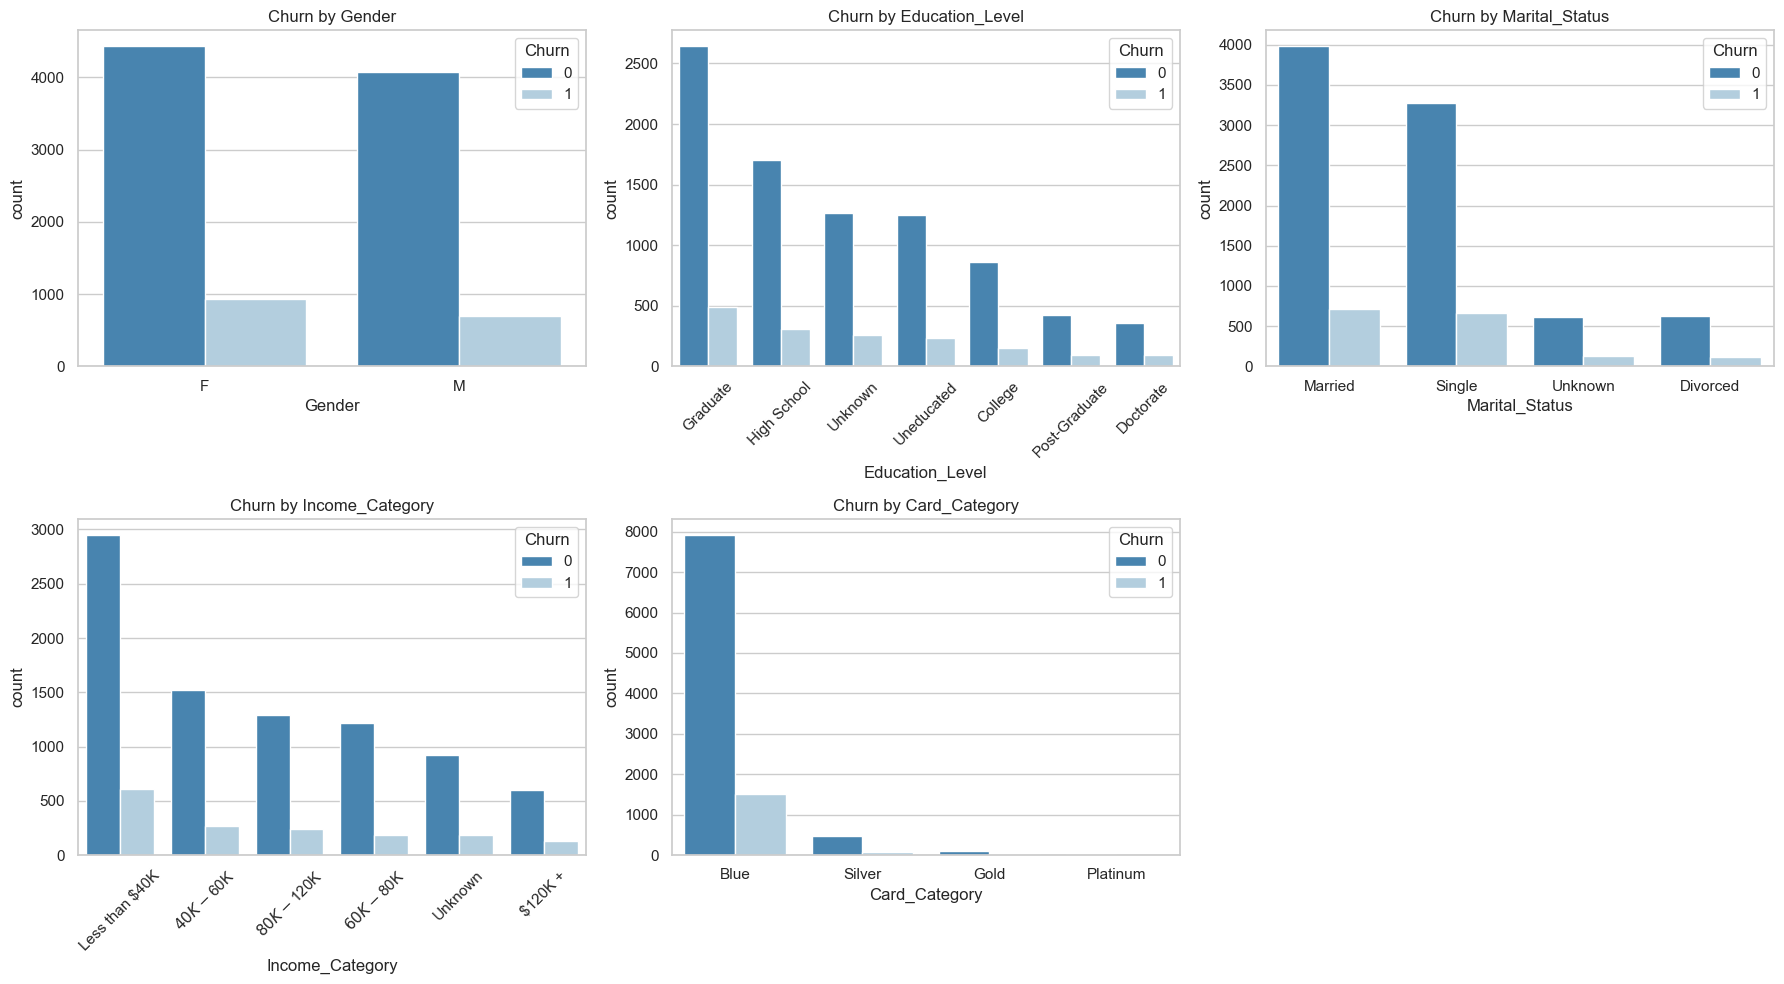

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    orders = df[col].value_counts().index
    sns.countplot(
        data=df,
        x=col,
        hue='Churn',
        order=orders,
        ax=axes[i],
        palette="Blues_r"
    )
    axes[i].set_title(f"Churn by {col}")

    if len(orders) > 4:
        axes[i].tick_params(axis='x', rotation=45)
    

# remove empty plot

fig.delaxes(axes[5])

plt.tight_layout()

plt.show()
    

### Initial Observation

Raw churn counts generally follow the size of each customer segment. Larger groups naturally contain more churned customers.

To identify true churn risk by segment, churn rates should be analyzed instead of absolute counts.

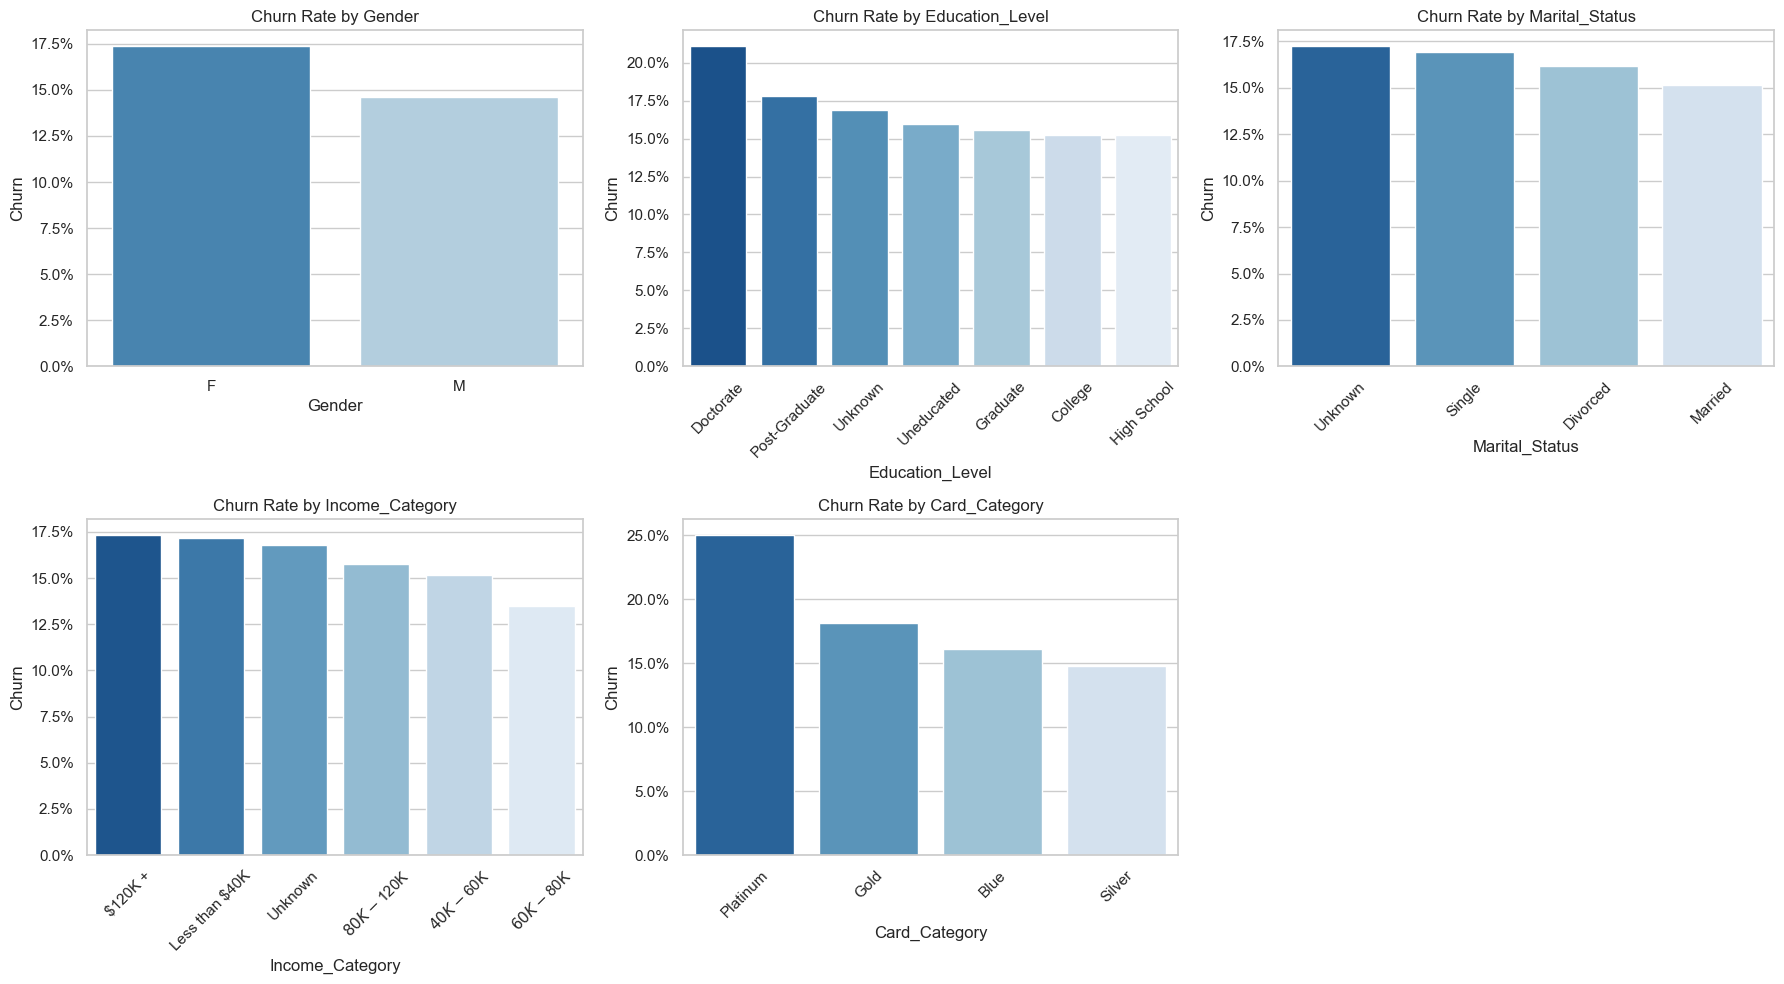

In [21]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    churn_rate = df.groupby(col)["Churn"].mean().reset_index()
    churn_rate = churn_rate.sort_values("Churn", ascending=False)
    
    sns.barplot(
        data=churn_rate,
        x=col,
        y="Churn",
        order=churn_rate[col],
        ax=axes[i],
        palette="Blues_r"
    )
    
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].yaxis.set_major_formatter(PercentFormatter(1))
    
    if len(churn_rate[col]) >= 4:
        axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

### Story Behind the Churn Patterns

The churn rate analysis shows that customer churn is not limited to one simple group.

Married customers are less likely to leave, which may suggest stronger long-term banking relationships and more stable financial needs. In contrast, Single and Unknown customers show higher churn rates, possibly reflecting lower attachment or more switching behavior.

Another interesting result is that premium customer groups such as Platinum, Gold, and high-income customers also show elevated churn rates. This suggests that high-value customers may have higher expectations and are more willing to switch when they do not receive enough value or service.

Female customers also show a slightly higher churn rate than male customers, which may indicate differences in customer experience or product fit.

Overall, the results suggest that the bank should not focus only on low-income churn risk. Both retail and premium customer groups require targeted retention strategies.

### 6.2 Churn vs Numerical Variables

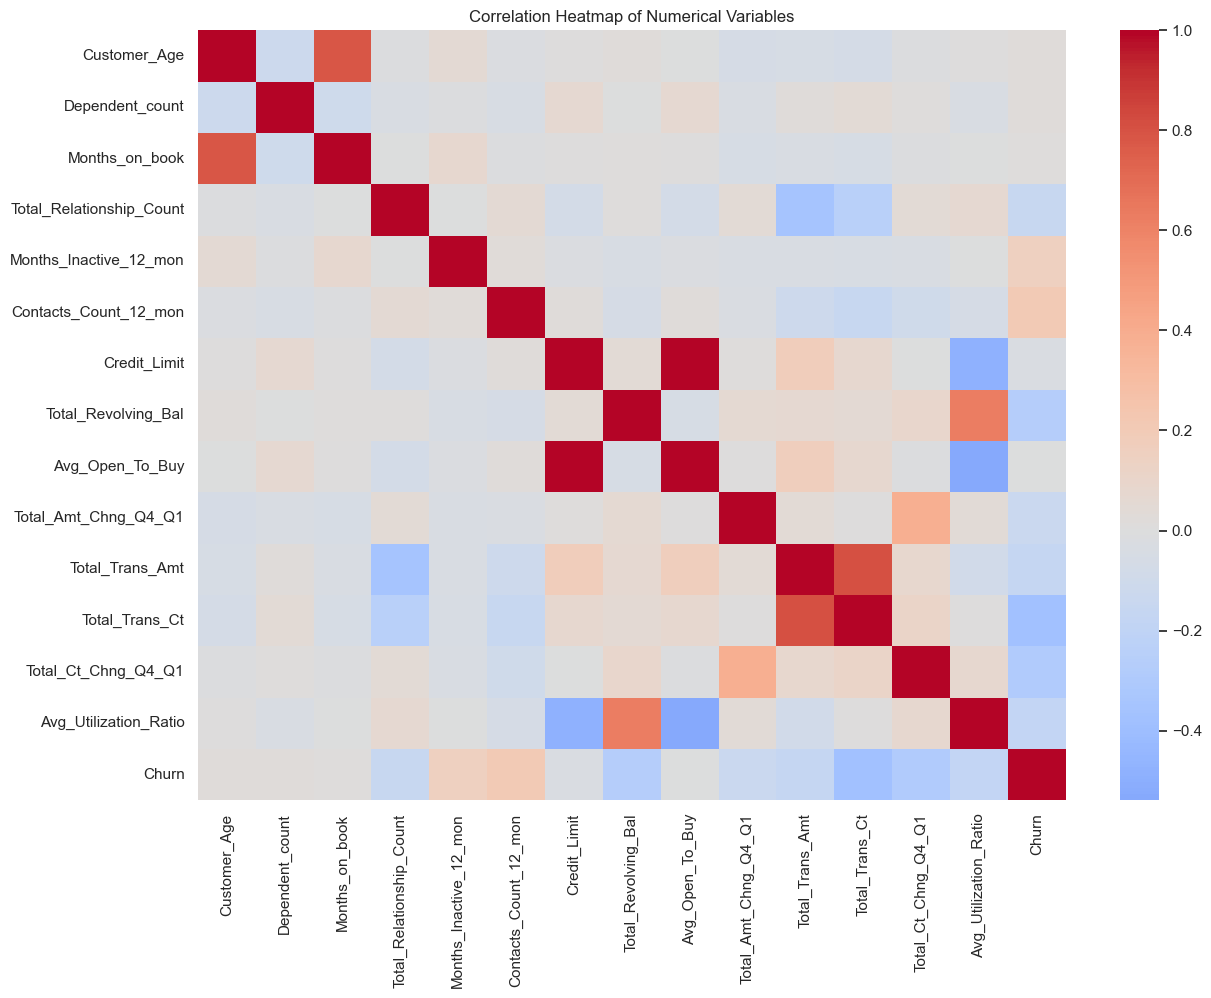

In [22]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()


### Key Insights from Numerical Correlation Heatmap

- `Total_Trans_Ct` and `Total_Trans_Amt` show a strong positive correlation. Customers who transact more often usually generate higher total transaction volume.

- `Credit_Limit` and `Avg_Open_To_Buy` are almost perfectly positively correlated. This is expected, as higher credit limits usually lead to more unused available credit.

- `Avg_Utilization_Ratio` has a strong positive correlation with `Total_Revolving_Bal` and a negative correlation with `Avg_Open_To_Buy`. Customers using more of their credit tend to carry higher balances.

- `Total_Amt_Chng_Q4_Q1` and `Total_Ct_Chng_Q4_Q1` show a positive relationship, meaning declining transaction count often comes together with declining transaction amount.

- Churn is negatively correlated with transaction count, transaction amount, and utilization ratio, suggesting churned customers are generally less active.

- Churn shows positive correlation with inactivity and contact count, meaning customers who are less active or contact the bank more often are more likely to churn.

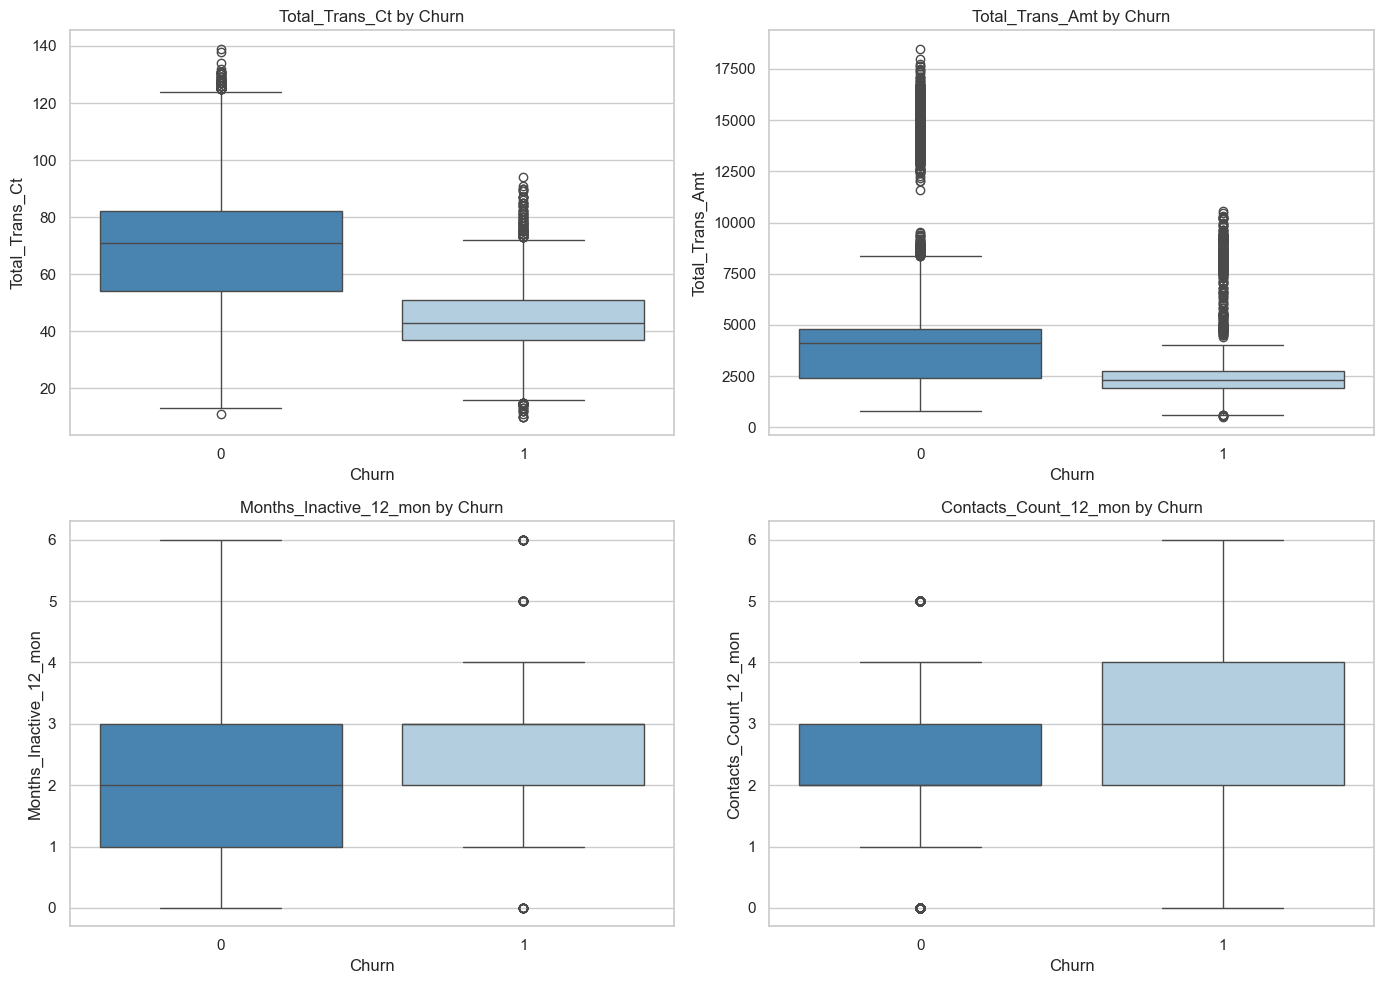

In [23]:
key_metrics = [
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon"
]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(key_metrics):
    
    sns.boxplot(
        data=df,
        x="Churn",
        y=col,
        ax=axes[i],
        palette="Blues_r"
    )
    
    axes[i].set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

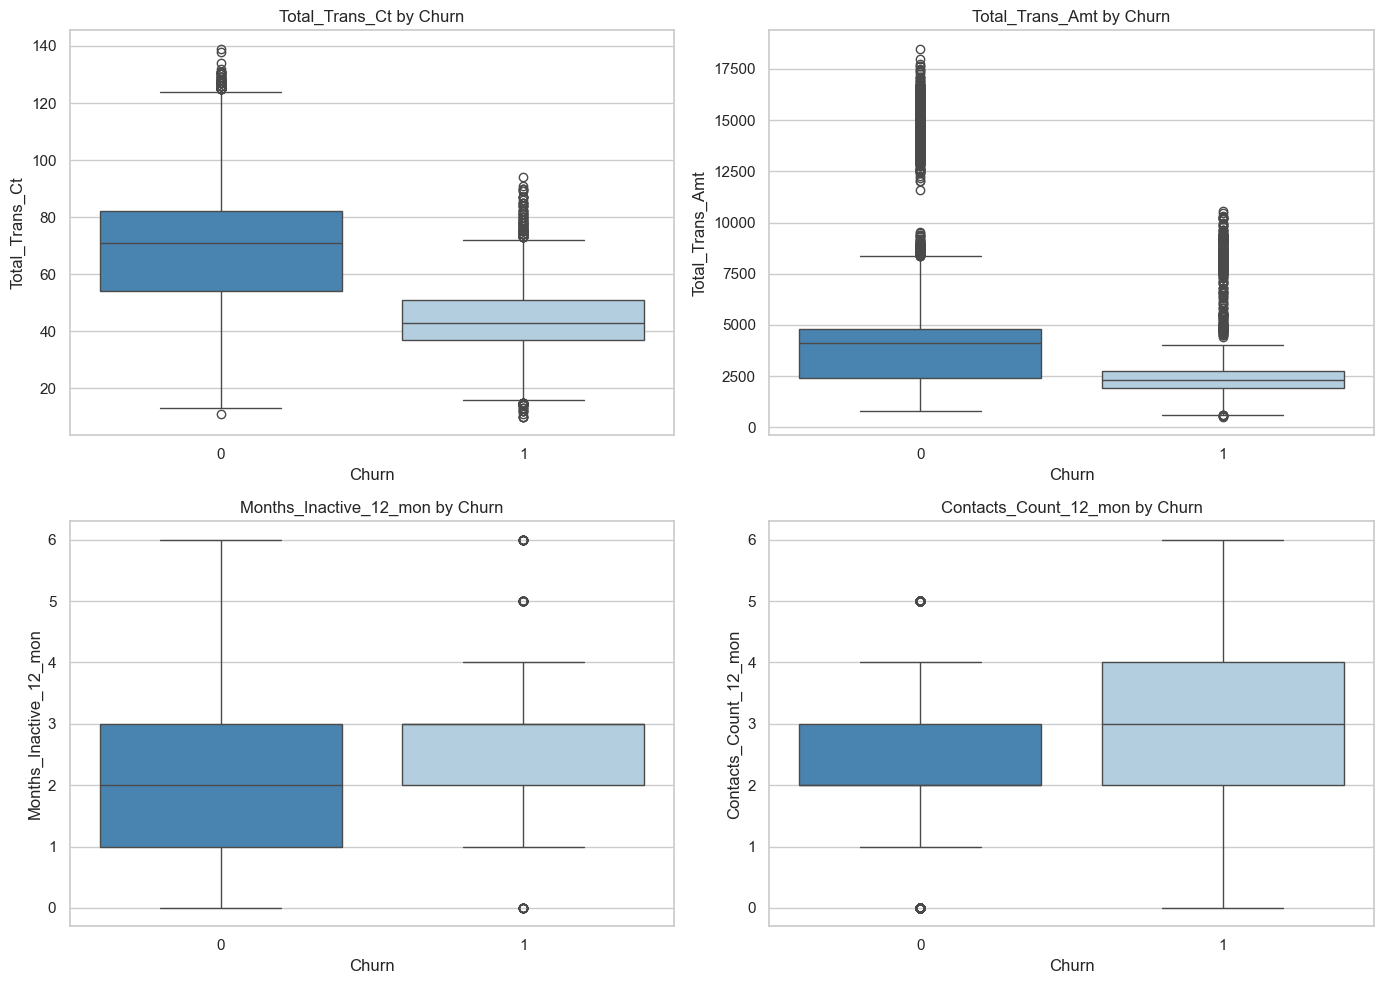

In [24]:
key_metrics = [
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon"
]

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(key_metrics):
    
    sns.boxplot(
        data=df,
        x="Churn",
        y=col,
        ax=axes[i],
        palette="Blues_r"
    )
    
    axes[i].set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

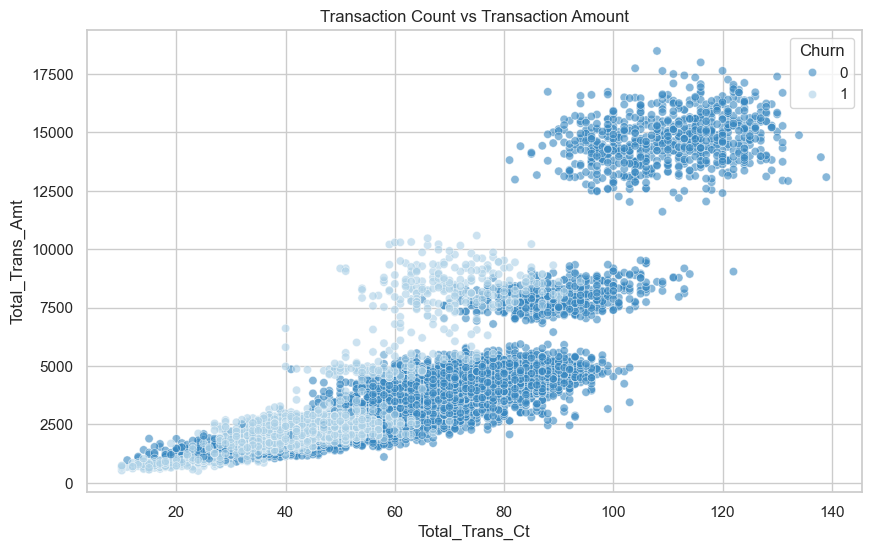

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Total_Trans_Ct",
    y="Total_Trans_Amt",
    hue="Churn",
    alpha=0.6,
    palette="Blues_r"
)

plt.title("Transaction Count vs Transaction Amount")
plt.show()

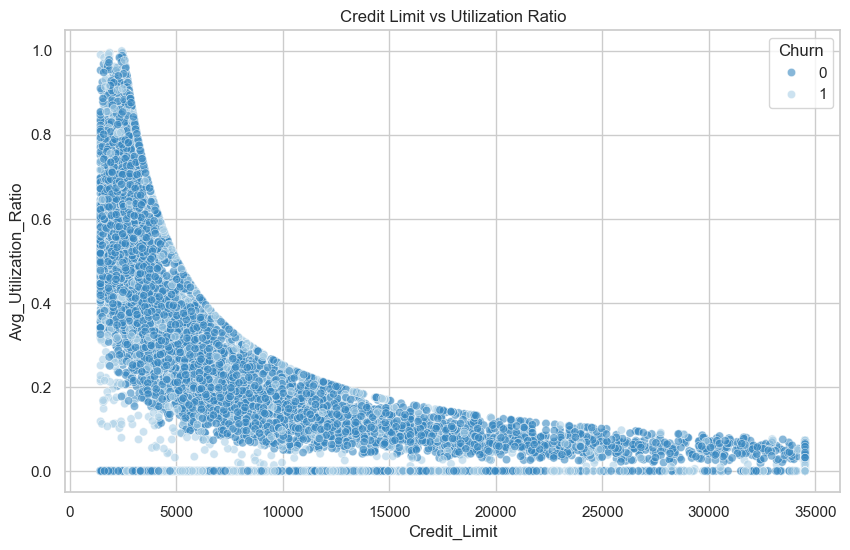

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Credit_Limit",
    y="Avg_Utilization_Ratio",
    hue="Churn",
    alpha=0.6,
    palette="Blues_r"
)

plt.title("Credit Limit vs Utilization Ratio")
plt.show()

### Key Insights from Numerical Variables

- Churned customers clearly have lower transaction count and lower transaction amount. This means customers who use the card less are more likely to leave.

- Churned customers also have more inactive months. Lower activity over time looks like an early warning signal before churn happens.

- Customers who contacted the bank more often also show higher churn. This may mean complaints, service issues, or dissatisfaction.

- Transaction count and transaction amount have a strong positive relationship. Customers who use the card more often usually spend more.

- In the transaction scatter plot, many churned customers are concentrated in lower and middle activity groups, while highly active customers are more likely to stay.

- Credit limit and utilization ratio show a clear negative relationship. Customers with high credit limits usually use a smaller share of their available limit.

- In the utilization chart, churned customers appear more often in the very low utilization area, suggesting low card usage is linked with churn.

In [27]:
df.to_csv("/Users/reyhaneh/Documents/Machine_Learning/credit-card-churn-analysis/data/cleaned_data.csv", index=False)

### Customer Churn Story

The analysis shows that customer churn is mainly linked to behavior changes, not only demographic factors.

Customers who leave usually reduce their card usage before churn happens. They have lower transaction count, lower transaction amount, higher inactivity, and often more contact with the bank. This suggests churn is often a gradual process, not a sudden event.

At the same time, some customer groups show higher churn rates. Female customers, single customers, and some premium segments such as Gold, Platinum, and high-income customers have above-average churn.

This means churn risk exists in both retail and premium customer groups.

Overall, the strongest warning signs are declining engagement and rising inactivity. If the bank monitors these signals early, targeted retention actions can be taken before customers leave.